# Proyecto: Predicción de cancelación de clientes en Beta Bank

## Objetivo general

Beta Bank está perdiendo clientes poco a poco cada mes, y al banco le sale más barato retener a un cliente que conseguir uno nuevo. Por eso necesita anticiparse y detectar quién está por irse antes de que ocurra.

En este proyecto construimos un modelo de clasificación que, a partir del comportamiento pasado de cada cliente, prediga si va a abandonar el banco. El requisito es alcanzar un **F1 de al menos 0.59 en el conjunto de prueba**. Además vamos a medir el **AUC-ROC** y comparar ambas métricas.

### Descripción de los datos

El archivo `Churn.csv` contiene 10 000 registros de clientes:

| Columna | Descripción |
|---|---|
| `RowNumber` | índice de la fila |
| `CustomerId` | identificador único del cliente |
| `Surname` | apellido |
| `CreditScore` | valor de crédito |
| `Geography` | país de residencia |
| `Gender` | sexo |
| `Age` | edad |
| `Tenure` | años de maduración del depósito a plazo fijo |
| `Balance` | saldo de la cuenta |
| `NumOfProducts` | número de productos bancarios contratados |
| `HasCrCard` | tiene tarjeta de crédito (1 sí / 0 no) |
| `IsActiveMember` | cliente activo (1 sí / 0 no) |
| `EstimatedSalary` | salario estimado |
| `Exited` | **objetivo**: el cliente se fue (1 sí / 0 no) |

## Paso 1: Preparación y exploración de los datos

**Objetivo:** revisar la calidad de los datos (tipos, valores ausentes, duplicados) y dejar el dataset listo para entrenar: todas las columnas numéricas, sin ausentes y solo con variables que digan algo del comportamiento del cliente.

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier  # modelo principal
from sklearn.tree import DecisionTreeClassifier  # modelo de contraste
from sklearn.model_selection import train_test_split  # para dividir el dataset
from sklearn.utils import shuffle  # para mezclar las filas tras el sobremuestreo
from sklearn.metrics import (  # métricas para evaluar la clasificación
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# cargamos el dataset de clientes del banco
df = pd.read_csv('Churn.csv')

In [71]:
# exploración inicial: estructura, contenido y estadísticas del dataset
df.info()  # tipos de dato y conteo de valores no nulos por columna
print()
print(df.head())  # primeras filas para inspeccionar el formato
print()
print(df.describe())  # estadísticas descriptivas de las columnas numéricas

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.2 MB

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave

In [72]:
# revisamos la calidad de los datos: ausentes y duplicados
print('Valores ausentes por columna:')
print(df.isnull().sum())
print()
print(f'Filas duplicadas: {df.duplicated().sum()}')
# CustomerId identifica de forma única a cada cliente: si se repitiera, habría clientes cargados dos veces
print(f'CustomerId duplicados: {df["CustomerId"].duplicated().sum()}')
print()
# categorías de las columnas de texto, para decidir cómo codificarlas más adelante
print(df['Geography'].value_counts())
print()
print(df['Gender'].value_counts())

Valores ausentes por columna:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Filas duplicadas: 0
CustomerId duplicados: 0

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Male      5457
Female    4543
Name: count, dtype: int64


### Valores ausentes en `Tenure`

`Tenure` es la única columna con datos faltantes, y por eso aparece como decimal y no como entero.

Antes de rellenarla queremos saber por qué faltan esos datos: si los clientes sin `Tenure` se comportaran distinto al resto, la ausencia sería información en sí misma y taparla con un solo valor introduciría un sesgo. Comparamos los dos grupos antes de decidir.

In [73]:
# máscara que separa las filas con Tenure ausente de las completas
tenure_ausente = df['Tenure'].isnull()

print(f'Filas con Tenure ausente: {tenure_ausente.sum()} ({tenure_ausente.mean():.2%})')
print()
# si la tasa de cancelación difiriera mucho entre ambos grupos, la ausencia estaría ligada al objetivo
print('Tasa de cancelación según Tenure ausente:')
print(df.groupby(tenure_ausente)['Exited'].mean())
print()
print('Distribución de Geography según Tenure ausente:')
print(df.groupby(tenure_ausente)['Geography'].value_counts(normalize=True).unstack())
print()
print('Perfil numérico promedio según Tenure ausente:')
print(df.groupby(tenure_ausente)[['Age', 'CreditScore', 'Balance', 'EstimatedSalary']].mean())

Filas con Tenure ausente: 909 (9.09%)

Tasa de cancelación según Tenure ausente:
Tenure
False    0.203938
True     0.201320
Name: Exited, dtype: float64

Distribución de Geography según Tenure ausente:
Geography    France   Germany     Spain
Tenure                                 
False      0.500495  0.252227  0.247278
True       0.510451  0.237624  0.251925

Perfil numérico promedio según Tenure ausente:
              Age  CreditScore       Balance  EstimatedSalary
Tenure                                                       
False   38.949181   650.736553  76522.740015    100181.214924
True    38.647965   648.451045  76117.341474     99180.389373


Los dos grupos son prácticamente iguales: misma tasa de cancelación, misma distribución por país y los mismos promedios de edad, crédito, saldo y salario. La ausencia no está ligada a ninguna característica del cliente ni al objetivo, así que podemos rellenarla sin distorsionar los datos.

Elegimos la mediana en lugar de la media porque no se ve afectada por valores extremos y devuelve un número entero de años, que es como se mide la variable (la media daría un decimal).

In [74]:
# rellenamos los ausentes con la mediana y devolvemos la columna a entero (años completos)
print(f'Mediana de Tenure: {df["Tenure"].median()}')
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median()).astype(int)

Mediana de Tenure: 5.0


### Columnas descartadas y codificación de las categóricas

`RowNumber` es solo un contador de filas y `CustomerId` un identificador arbitrario: ninguno dice nada sobre el comportamiento del cliente. `Surname` tampoco, y además tiene miles de valores distintos, así que al codificarlo generaría un montón de columnas y el modelo terminaría memorizando apellidos en vez de aprender patrones. Descartamos las tres.

`Geography` y `Gender` sí aportan información, pero son texto y scikit-learn solo trabaja con números. Las pasamos a One-Hot Encoding con `drop_first=True`: con tres países bastan dos columnas, porque la tercera queda implícita. No usamos una codificación tipo France=0, Germany=1, Spain=2 porque inventaría un orden entre países que no existe.

In [75]:
# eliminamos las columnas identificadoras, que no aportan información predictiva
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# codificamos las variables categóricas con One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [76]:
# verificación final: ninguna columna de texto y ningún valor ausente
df.info()
print()
print(df.head())
print()
print(f'Valores ausentes totales: {df.isnull().sum().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.6 KB

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   838

**Conclusión:** el dataset traía 10 000 registros y 14 columnas, sin filas duplicadas ni `CustomerId` repetidos.

La única columna con ausentes era `Tenure`: 909 valores, un 9.09 % del total. Las filas afectadas tienen la misma tasa de cancelación que el resto (20.1 % frente a 20.4 %) y el mismo perfil de país, edad, crédito, saldo y salario, así que las rellenamos con la mediana (5 años) y devolvimos la columna a entero.

Después de descartar las tres columnas identificadoras y codificar `Geography` y `Gender`, quedamos con **10 000 filas y 12 columnas**: 11 características y el objetivo `Exited`. Sin valores ausentes y con todo en formato numérico, los datos ya están listos para entrenar.

## Paso 2: Examen del equilibrio de clases y modelo base

**Objetivo:** medir qué tan desequilibradas están las clases, dividir los datos en entrenamiento, validación y prueba, y entrenar un primer modelo sin corregir ese desequilibrio para tener una referencia contra la cual comparar las mejoras del paso 3.

In [77]:
# trabajamos sobre una copia para no alterar el DataFrame original
df_modelo = df.copy()

# separamos las características de la columna objetivo
features = df_modelo.drop('Exited', axis=1)
target = df_modelo['Exited']

# proporción de clases, en número y en porcentaje
print(target.value_counts())
print()
print(target.value_counts(normalize=True) * 100)

Exited
0    7963
1    2037
Name: count, dtype: int64

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


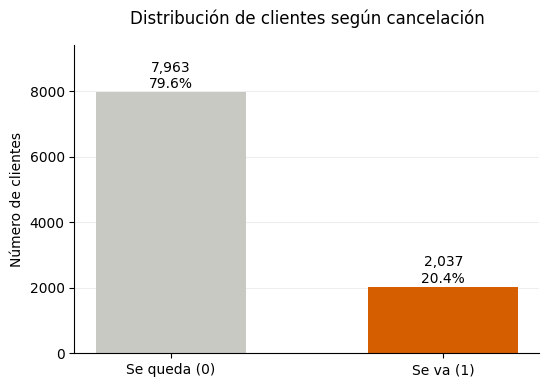

In [78]:
# visualizamos el desequilibrio para dimensionarlo de un vistazo
conteo = target.value_counts().sort_index()
proporcion = target.value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
# gris para la mayoría y naranja para la clase que nos interesa detectar
barras = ax.bar(['Se queda (0)', 'Se va (1)'], conteo.values, color=['#c9c9c4', '#D55E00'], width=0.55)

# etiquetamos cada barra con la cantidad y el porcentaje
for barra, cantidad, porcentaje in zip(barras, conteo.values, proporcion.values):
    ax.text(barra.get_x() + barra.get_width() / 2, cantidad + 120,
            f'{cantidad:,}\n{porcentaje:.1%}', ha='center', fontsize=10)

ax.set_title('Distribución de clientes según cancelación', fontsize=12, pad=15)
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, conteo.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

Las clases están desequilibradas: casi el 80 % de los clientes se queda y solo el 20 % se va, 1 de cada 5. Con esa proporción, un modelo que dijera siempre "se queda" acertaría el 80 % de las veces sin haber aprendido nada, así que la exactitud no nos sirve como métrica principal.

### División en entrenamiento, validación y prueba

Repartimos los datos en 60 % entrenamiento, 20 % validación y 20 % prueba. Usamos `stratify` para que los tres conjuntos conserven la misma proporción de clientes que se van: siendo la clase minoritaria solo el 20 %, una división al azar puede dejar proporciones distintas en cada conjunto y la comparación entre modelos dejaría de ser justa.

El conjunto de validación es el que usaremos para elegir el mejor modelo. El de prueba queda reservado y no lo tocamos hasta el paso 4.

In [79]:
# primer corte: 60% para entrenamiento y 40% que repartiremos entre validación y prueba
features_train, features_rest, target_train, target_rest = train_test_split(
    features, target, test_size=0.4, random_state=12345, stratify=target
)

# segundo corte: partimos ese 40% por la mitad → 20% validación y 20% prueba
features_valid, features_test, target_valid, target_test = train_test_split(
    features_rest, target_rest, test_size=0.5, random_state=12345, stratify=target_rest
)

# comprobamos los tamaños y que la proporción de clientes que se van se haya conservado
for nombre, conjunto in [('Entrenamiento', target_train), ('Validación', target_valid), ('Prueba', target_test)]:
    print(f'{nombre}: {len(conjunto)} filas, {conjunto.mean():.2%} de clientes que se van')

Entrenamiento: 6000 filas, 20.37% de clientes que se van
Validación: 2000 filas, 20.40% de clientes que se van
Prueba: 2000 filas, 20.35% de clientes que se van


### Modelo base sin corregir el desequilibrio

Entrenamos un bosque aleatorio con los hiperparámetros por defecto y sin tocar el desequilibrio, para tener una referencia de partida. El ajuste de hiperparámetros y las técnicas de balanceo llegan en el paso 3.

Definimos primero una función que calcule todas las métricas de golpe, así la reutilizamos con cada modelo que entrenemos.

In [80]:
# función para calcular de una sola vez todas las métricas y poder comparar modelos después
def evaluar_modelo(nombre, modelo, features, target):
    predicciones = modelo.predict(features)
    # el AUC-ROC se calcula con la probabilidad de la clase 1, no con la etiqueta predicha
    probabilidades = modelo.predict_proba(features)[:, 1]

    return {
        'modelo': nombre,
        'exactitud': accuracy_score(target, predicciones),
        'precisión': precision_score(target, predicciones),
        'recall': recall_score(target, predicciones),
        'F1': f1_score(target, predicciones),
        'AUC-ROC': roc_auc_score(target, probabilidades),
    }

In [81]:
# entrenamos el modelo base con los hiperparámetros por defecto, sin corregir el desequilibrio
modelo_base = RandomForestClassifier(random_state=12345)
modelo_base.fit(features_train, target_train)

resultado_base = evaluar_modelo('Bosque aleatorio (sin balancear)', modelo_base, features_valid, target_valid)
pd.DataFrame([resultado_base])

,modelo,exactitud,precisión,recall,F1,AUC-ROC
0,Bosque aleatorio (sin balancear),0.868,0.768657,0.504902,0.609467,0.862824


In [82]:
# la matriz de confusión nos deja ver cuántos clientes que sí se fueron el modelo dejó pasar
print('Matriz de confusión (validación):')
print(confusion_matrix(target_valid, modelo_base.predict(features_valid)))

Matriz de confusión (validación):
[[1530   62]
 [ 202  206]]


Para dimensionar el resultado lo comparamos contra un modelo constante que predice que ningún cliente se va. Es el peor modelo posible desde el punto de vista del negocio, y sirve para ver cuánta exactitud se puede conseguir sin aprender nada.

In [83]:
# modelo constante que predice que ningún cliente se va, como punto de comparación
predicciones_constantes = pd.Series(0, index=target_valid.index)

print(f'Exactitud: {accuracy_score(target_valid, predicciones_constantes):.4f}')
print(f'Recall: {recall_score(target_valid, predicciones_constantes):.4f}')
print(f'F1: {f1_score(target_valid, predicciones_constantes):.4f}')

Exactitud: 0.7960
Recall: 0.0000
F1: 0.0000


**Conclusión:** las clases están desequilibradas en una proporción cercana al 80/20: 7 963 clientes se quedaron y 2 037 se fueron, es decir 1 de cada 5.

El bosque aleatorio entrenado sin corregir ese desequilibrio alcanza una exactitud del 86.8 % y una precisión de 0.77, pero su recall es de apenas 0.50. Mirando la matriz de confusión: de los 408 clientes del conjunto de validación que sí se fueron, el modelo detectó 206 y dejó pasar 202. Cuando dice que un cliente se va suele acertar, pero se le escapa la mitad de los que realmente se van, que es justo el grupo que al banco le interesa retener.

El F1 quedó en 0.6095 y el AUC-ROC en 0.8628. Llama la atención que el F1 ya supere el umbral de 0.59 sin haber corregido nada: el bosque aleatorio tolera bastante bien el desequilibrio. Aun así este número es sobre validación, no sobre prueba, y con la mitad de los clientes en riesgo sin detectar hay margen claro de mejora en el paso 3.

Como referencia, un modelo que predijera que ningún cliente se va obtendría un 79.6 % de exactitud con un F1 de 0. Eso confirma que la exactitud no sirve para medir este problema y que las métricas a seguir son el F1 y el recall.

## Paso 3: Corrección del desequilibrio de clases

**Objetivo:** corregir el desequilibrio con dos técnicas distintas —pesos de clase y sobremuestreo— y ajustar los hiperparámetros de cada modelo, usando el conjunto de validación para elegir el mejor.

**Hipótesis:** el modelo del paso anterior falla en el recall, que es la métrica que nos dice cuántos de los clientes que efectivamente se fueron logramos identificar. Esperamos que al equilibrar las clases el modelo deje de ignorar a la minoría, suba el recall y con él el F1, que es la media armónica entre precisión y recall.

También esperamos que la exactitud baje un poco: al predecir más cancelaciones aumentan las falsas alarmas. Ese intercambio nos conviene mientras el F1 mejore, porque para el banco es más caro perder a un cliente que no detectamos que contactar a uno que se iba a quedar de todos modos.

### Las dos técnicas de balanceo

**Pesos de clase (`class_weight='balanced'`):** el modelo sigue viendo los mismos datos, pero los errores sobre la clase minoritaria pesan más al construir los árboles, así que deja de resultarle cómodo ignorarla.

**Sobremuestreo:** repetimos las filas de los clientes que se fueron hasta igualar a los que se quedaron. Como la proporción es de 1 a 4, con cuatro repeticiones el conjunto queda equilibrado.

In [84]:
# repetimos las filas de la clase minoritaria hasta equilibrar el conjunto
def sobremuestrear(features, target, repeticiones):
    features_ceros = features[target == 0]
    features_unos = features[target == 1]
    target_ceros = target[target == 0]
    target_unos = target[target == 1]

    features_ampliadas = pd.concat([features_ceros] + [features_unos] * repeticiones)
    target_ampliado = pd.concat([target_ceros] + [target_unos] * repeticiones)

    # mezclamos para que las filas repetidas no queden todas juntas al final
    return shuffle(features_ampliadas, target_ampliado, random_state=12345)


# solo sobre el conjunto de entrenamiento: validación y prueba conservan la proporción real
features_upsampled, target_upsampled = sobremuestrear(features_train, target_train, 4)

print(f'Entrenamiento original: {len(target_train)} filas')
print(f'Entrenamiento ampliado: {len(target_upsampled)} filas')
print()
print(target_upsampled.value_counts(normalize=True))

Entrenamiento original: 6000 filas
Entrenamiento ampliado: 9666 filas

Exited
1    0.50569
0    0.49431
Name: proportion, dtype: float64


### Ajuste de hiperparámetros

Entrenamos tres bosques aleatorios —sin balancear, con pesos de clase y con sobremuestreo— probando en cada uno distintas combinaciones de `n_estimators` y `max_depth`. Nos quedamos con la combinación que dé el mejor F1 sobre el conjunto de validación, para que la comparación entre técnicas sea entre las mejores versiones de cada una y no entre configuraciones elegidas al azar.

In [85]:
# probamos combinaciones de hiperparámetros y nos quedamos con la de mejor F1 en validación
def buscar_mejor_bosque(features_entrenamiento, target_entrenamiento, peso=None):
    mejor_modelo, mejor_f1, mejor_combinacion = None, 0, None

    for n_arboles in (50, 100, 150):
        for profundidad in (5, 6, 7, 8, 9, 10, 12, 15, None):
            modelo = RandomForestClassifier(
                n_estimators=n_arboles,
                max_depth=profundidad,
                class_weight=peso,
                random_state=12345,
            )
            modelo.fit(features_entrenamiento, target_entrenamiento)
            # el F1 se mide siempre sobre validación, que es el conjunto con el que elegimos
            f1 = f1_score(target_valid, modelo.predict(features_valid))

            if f1 > mejor_f1:
                mejor_f1 = f1
                mejor_modelo = modelo
                mejor_combinacion = (n_arboles, profundidad)

    return mejor_modelo, mejor_combinacion

In [86]:
# buscamos los mejores hiperparámetros para cada uno de los tres escenarios
# (la búsqueda completa tarda cerca de medio minuto)

# referencia: sin corregir el desequilibrio, pero ya con hiperparámetros ajustados
modelo_sin_balancear, params_sin_balancear = buscar_mejor_bosque(features_train, target_train)

# técnica 1: pesos de clase
modelo_pesos, params_pesos = buscar_mejor_bosque(features_train, target_train, peso='balanced')

# técnica 2: sobremuestreo (entrenamos con el conjunto ampliado)
modelo_sobremuestreo, params_sobremuestreo = buscar_mejor_bosque(features_upsampled, target_upsampled)

print(f'Sin balancear      -> n_estimators={params_sin_balancear[0]}, max_depth={params_sin_balancear[1]}')
print(f'class_weight       -> n_estimators={params_pesos[0]}, max_depth={params_pesos[1]}')
print(f'Sobremuestreo      -> n_estimators={params_sobremuestreo[0]}, max_depth={params_sobremuestreo[1]}')

Sin balancear      -> n_estimators=50, max_depth=15
class_weight       -> n_estimators=100, max_depth=10
Sobremuestreo      -> n_estimators=50, max_depth=10


In [87]:
# comparamos el modelo base del paso 2 contra los tres modelos ajustados de este paso
resultados = pd.DataFrame([
    resultado_base,
    evaluar_modelo('Bosque ajustado (sin balancear)', modelo_sin_balancear, features_valid, target_valid),
    evaluar_modelo("Bosque con class_weight='balanced'", modelo_pesos, features_valid, target_valid),
    evaluar_modelo('Bosque con sobremuestreo', modelo_sobremuestreo, features_valid, target_valid),
]).sort_values('F1', ascending=False).reset_index(drop=True)

resultados

,modelo,exactitud,precisión,recall,F1,AUC-ROC
0,Bosque con class_weight='balanced',0.8395,0.585462,0.730392,0.649945,0.871450
1,Bosque con sobremuestreo,0.8360,0.577821,0.727941,0.644252,0.866857
2,Bosque ajustado (sin balancear),0.8690,0.772388,0.507353,0.612426,0.863123
3,Bosque aleatorio (sin balancear),0.8680,0.768657,0.504902,0.609467,0.862824


La curva ROC muestra qué tan bien ordena cada modelo a los clientes por riesgo de cancelación, recorriendo todos los umbrales posibles en lugar de quedarse solo en el de 0.5. Incluimos el AUC y el F1 de cada modelo en la leyenda para poder contrastarlos directamente.

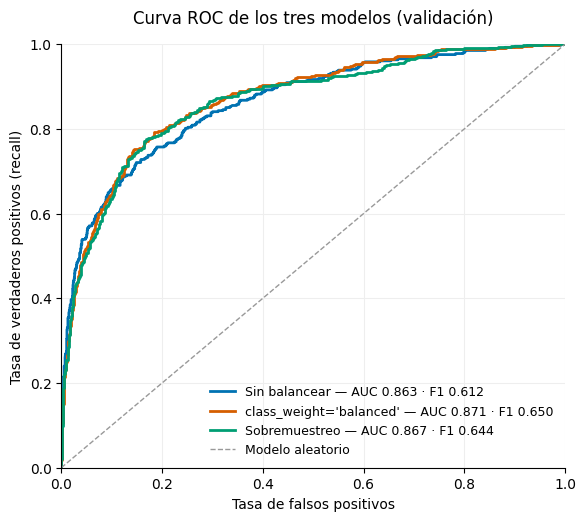

In [88]:
# curva ROC de los tres modelos, con su AUC y su F1 juntos para poder contrastarlos
modelos_roc = [
    ('Sin balancear', modelo_sin_balancear, '#0072B2'),
    ("class_weight='balanced'", modelo_pesos, "#D55E00"),
    ('Sobremuestreo', modelo_sobremuestreo, '#009E73'),
]

fig, ax = plt.subplots(figsize=(6.5, 5.5))

for nombre, modelo, color in modelos_roc:
    probabilidades = modelo.predict_proba(features_valid)[:, 1]
    tasa_falsos_positivos, tasa_verdaderos_positivos, _ = roc_curve(target_valid, probabilidades)
    auc = roc_auc_score(target_valid, probabilidades)
    f1 = f1_score(target_valid, modelo.predict(features_valid))
    ax.plot(tasa_falsos_positivos, tasa_verdaderos_positivos, color=color, linewidth=2,
            label=f'{nombre} — AUC {auc:.3f} · F1 {f1:.3f}')

# la diagonal es el modelo que no distingue nada, equivalente a lanzar una moneda
ax.plot([0, 1], [0, 1], color='#999999', linewidth=1, linestyle='--', label='Modelo aleatorio')

ax.set_title('Curva ROC de los tres modelos (validación)', fontsize=12, pad=15)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos (recall)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.show()

### Contraste con otra familia de modelos

Hasta aquí solo hemos usado bosques aleatorios. Entrenamos también un árbol de decisión balanceado para comprobar que la ganancia viene del modelo y no únicamente del balanceo de clases.

In [89]:
# buscamos la mejor profundidad para el árbol, con el mismo criterio que usamos con los bosques
mejor_arbol, mejor_f1_arbol, mejor_profundidad_arbol = None, 0, None

for profundidad in range(1, 21):
    arbol = DecisionTreeClassifier(max_depth=profundidad, class_weight='balanced', random_state=12345)
    arbol.fit(features_train, target_train)
    f1_arbol = f1_score(target_valid, arbol.predict(features_valid))

    if f1_arbol > mejor_f1_arbol:
        mejor_f1_arbol = f1_arbol
        mejor_arbol = arbol
        mejor_profundidad_arbol = profundidad

print(f'Mejor árbol de decisión: max_depth={mejor_profundidad_arbol}')
pd.DataFrame([evaluar_modelo('Árbol de decisión balanceado', mejor_arbol, features_valid, target_valid)])

Mejor árbol de decisión: max_depth=6


,modelo,exactitud,precisión,recall,F1,AUC-ROC
0,Árbol de decisión balanceado,0.771,0.462798,0.762255,0.575926,0.823327


**Conclusión:** las dos técnicas de balanceo mejoraron el modelo, y lo hicieron justo donde la hipótesis anticipaba.

El bosque sin balancear, incluso con los hiperparámetros ya ajustados, se queda en un F1 de 0.6124 con un recall de 0.5074: sigue detectando apenas la mitad de los clientes que se van. Con `class_weight='balanced'` el recall sube a 0.7304 y el F1 a 0.6499, y con sobremuestreo llegamos a 0.7279 de recall y 0.6443 de F1. Las dos técnicas recuperan alrededor de 22 puntos de recall y quedan muy parejas entre sí.

El precio es la precisión, que cae de 0.77 a 0.59, y la exactitud, que baja del 86.9 % al 84.0 %. El modelo señala ahora más clientes que en realidad se iban a quedar, pero identifica a 3 de cada 4 de los que sí se van, frente a 1 de cada 2 antes. Para el banco el intercambio es favorable: una falsa alarma cuesta una llamada del equipo de retención, mientras que un cliente no detectado se pierde.

El AUC-ROC, en cambio, casi no se mueve entre los tres modelos (0.8631, 0.8714 y 0.8669), y en la curva ROC las tres líneas quedan prácticamente superpuestas aunque sus F1 vayan de 0.612 a 0.650. Esto se explica porque balancear las clases no hace que el modelo distinga mejor a los clientes, solo cambia el punto a partir del cual decide que alguien se va. El F1 sí lo refleja porque se calcula sobre las etiquetas predichas con el umbral de 0.5, mientras que el AUC-ROC evalúa el ordenamiento completo de las probabilidades y es indiferente a ese umbral.

Como contraste, el árbol de decisión balanceado se queda en un F1 de 0.5759, por debajo del umbral exigido por el proyecto, lo que confirma que el bosque aleatorio el modelo adecuado para este problema.

**Modelo ganador:** bosque aleatorio con `class_weight='balanced'`, `n_estimators=100` y `max_depth=10`. Es el que llevamos a la prueba final.

## Paso 4: Prueba final

**Objetivo:** medir el rendimiento real del modelo ganador sobre el **conjunto de prueba**, que separamos en el paso 2.

Antes de evaluarlo reentrenamos el bosque ganador —`class_weight='balanced'`, `n_estimators=100`, `max_depth=10`— con entrenamiento y validación juntos. Los hiperparámetros ya están decididos, así que aprovechamos el 80 % de los datos en lugar del 60 % para que el modelo llegue a la prueba con toda la información disponible.

In [90]:
# reentrenamos el modelo ganador con entrenamiento + validación (el 80% de los datos)
features_completo = pd.concat([features_train, features_valid])
target_completo = pd.concat([target_train, target_valid])

modelo_final = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=12345
)
modelo_final.fit(features_completo, target_completo)

predicciones_finales = modelo_final.predict(features_test)

# comparamos el resultado en validación contra el del conjunto de prueba
pd.DataFrame([
    evaluar_modelo('Modelo ganador (validación)', modelo_pesos, features_valid, target_valid),
    evaluar_modelo('Modelo final (PRUEBA)', modelo_final, features_test, target_test),
])

,modelo,exactitud,precisión,recall,F1,AUC-ROC
0,Modelo ganador (validación),0.8395,0.585462,0.730392,0.649945,0.871450
1,Modelo final (PRUEBA),0.8180,0.541586,0.687961,0.606061,0.859184


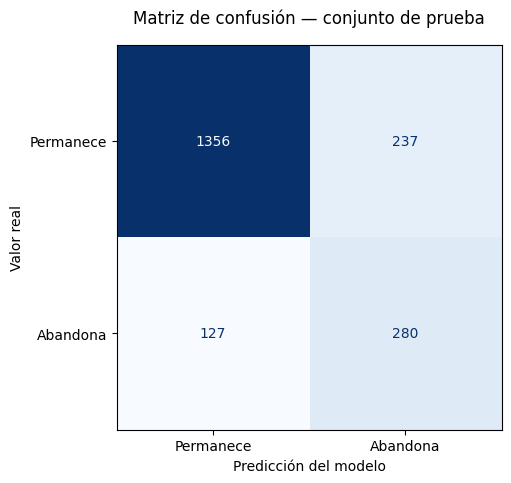

In [97]:
# matriz de confusión del modelo final sobre el conjunto de prueba
matriz = confusion_matrix(target_test, predicciones_finales)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Permanece', 'Abandona']).plot(
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Matriz de confusión — conjunto de prueba', fontsize=12, pad=15)
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Valor real')
ax.grid(False)
plt.show()

**Conclusión:** el modelo final alcanza un **F1 de 0.6061 sobre el conjunto de prueba**, por encima del umbral de 0.59 que exige el proyecto, con un AUC-ROC de 0.8592.

El F1 bajó respecto al 0.6499 que habíamos medido en validación, y era de esperarse: sobre validación probamos 81 combinaciones y nos quedamos con la que mejor puntuaba ahí, así que ese número estaba optimizado para ese conjunto. La prueba, que el modelo nunca vio ni influyó en ninguna decisión, da la estimación honesta de cómo se comportará con clientes nuevos.

Leyendo los cuatro cuadrantes de la matriz de confusión sobre los 2 000 clientes del conjunto de prueba:

| Cuadrante | Casos | Qué significa para el banco |
|---|---|---|
| **Verdaderos negativos** (arriba izq.) | 1 356 | clientes que se quedaron y el modelo predijo bien; no requieren acción |
| **Falsos positivos** (arriba der.) | 237 | el modelo los señaló como en riesgo pero se iban a quedar: falsas alarmas, cuestan una gestión de retención innecesaria |
| **Falsos negativos** (abajo izq.) | 127 | se fueron y el modelo no los detectó: es el error caro, son clientes perdidos sin oportunidad de intervenir |
| **Verdaderos positivos** (abajo der.) | 280 | se fueron y el modelo los identificó a tiempo: son los casos que justifican el proyecto |

De los 407 clientes que efectivamente cancelaron, el modelo detectó 280, es decir un **recall de 0.688**: casi 7 de cada 10. La precisión es de 0.542, así que de cada 100 clientes que el modelo señala, unos 54 se iban de verdad.

El balance entre ambos errores favorece al banco. Las 237 falsas alarmas se traducen en llamadas u ofertas a clientes que no pensaban irse —un costo operativo bajo y recuperable—, mientras que cada uno de los 127 falsos negativos es un cliente perdido de forma definitiva. Preferir este reparto sobre el del modelo sin balancear, que dejaba escapar a la mitad de los clientes en riesgo, es la decisión correcta para el negocio.

### ¿Qué características pesan más en la predicción?

El bosque aleatorio permite consultar cuánto aportó cada característica a las decisiones de sus árboles. Esto no forma parte de los requisitos del proyecto, pero responde una pregunta útil para el banco: además de cuántos clientes se van, quiénes son.

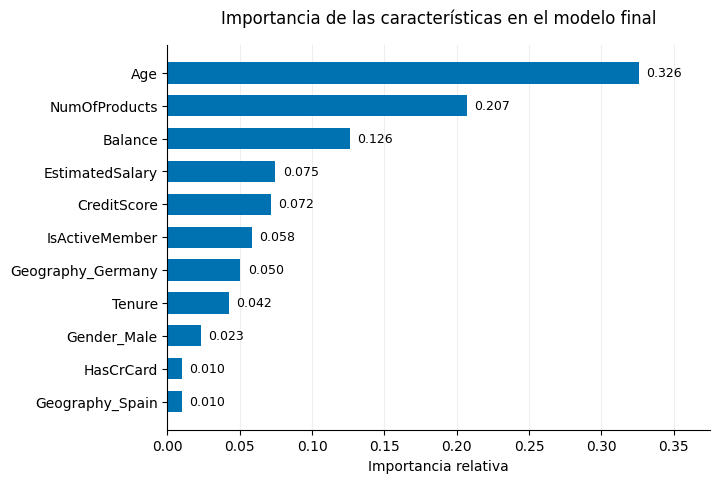

In [98]:
# importancia que el modelo final asignó a cada característica
importancias = pd.Series(
    modelo_final.feature_importances_, index=features.columns
).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importancias.index, importancias.values, color='#0072B2', height=0.65)

# etiquetamos cada barra con su valor
for nombre, valor in importancias.items():
    ax.text(valor + 0.005, nombre, f'{valor:.3f}', va='center', fontsize=9)

ax.set_title('Importancia de las características en el modelo final', fontsize=12, pad=15)
ax.set_xlabel('Importancia relativa')
ax.set_xlim(0, importancias.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

La edad es con diferencia la característica más determinante (0.326), seguida del número de productos contratados (0.207) y del saldo de la cuenta (0.126). Entre las tres explican cerca del 66 % de las decisiones del modelo. En el extremo opuesto, tener tarjeta de crédito (0.010) y residir en España (0.010) son prácticamente irrelevantes.

Conviene leer estos valores con cautela: la importancia por impureza que calcula el bosque tiende a favorecer a las variables continuas con muchos valores distintos frente a las binarias. Por eso `EstimatedSalary` (0.075) aparece por encima de `IsActiveMember` (0.058) sin que eso signifique necesariamente que el salario prediga mejor la cancelación.

## Conclusiones generales

### Cumplimiento de los requisitos del proyecto

**El objetivo se alcanzó: el modelo final obtuvo un F1 de 0.6061 sobre el conjunto de prueba, por encima del mínimo de 0.59 exigido**, con un AUC-ROC de 0.8592.

Recorrido del proyecto:

| Requisito | Cómo se resolvió |
|---|---|
| Preparar los datos | Se rellenaron los 909 ausentes de `Tenure` con la mediana, tras verificar que su ausencia era aleatoria; se descartaron las tres columnas identificadoras y se codificaron `Geography` y `Gender` con One-Hot Encoding |
| Examinar el equilibrio de clases | Proporción de 79.6 % / 20.4 %, medida y graficada; se comprobó que un modelo constante alcanza 79.6 % de exactitud con F1 de 0 |
| Entrenar sin corregir el desequilibrio | Bosque aleatorio con parámetros por defecto: exactitud 86.8 % pero recall de solo 0.505 |
| Dividir los datos | 60 / 20 / 20 en entrenamiento, validación y prueba, con `stratify` para conservar la proporción de clases en los tres conjuntos |
| Usar dos técnicas de balanceo | `class_weight='balanced'` y sobremuestreo de la clase minoritaria, cada una con su propia búsqueda de hiperparámetros |
| Encontrar el mejor modelo y parámetros | 81 bosques evaluados sobre validación, más un árbol de decisión como contraste; ganó el bosque con pesos de clase, `n_estimators=100`, `max_depth=10` |
| Prueba final | El modelo ganador se reentrenó con entrenamiento + validación y se midió una sola vez sobre el conjunto de prueba |
| Examinar el AUC-ROC | Medido en todos los modelos y comparado con el F1 |

**Sobre la comparación entre F1 y AUC-ROC**, que era el segundo objetivo del proyecto: al corregir el desequilibrio el F1 pasó de 0.6095 a 0.6499 en validación, mientras que el AUC-ROC apenas se movió, de 0.8628 a 0.8714. En la curva ROC las tres variantes quedan prácticamente superpuestas.

La explicación es que ambas métricas miden cosas distintas. El F1 se calcula sobre las etiquetas que el modelo predice con el umbral de 0.5, así que cambia en cuanto el balanceo desplaza ese punto de corte. El AUC-ROC evalúa el ordenamiento completo de las probabilidades y es indiferente al umbral, por lo que refleja la capacidad de discriminación del modelo, que el balanceo no altera. Dicho de otro modo: equilibrar las clases no hizo que el modelo entendiera mejor a los clientes, sino que dejara de ignorar a la minoría al momento de decidir.

De ahí la lección práctica del proyecto: con clases desequilibradas la exactitud engaña, el AUC-ROC dice si el modelo distingue, y el F1 dice si además está tomando la decisión correcta.

### Recomendación para el negocio

El modelo identifica a **7 de cada 10 clientes que van a cancelar** (recall de 0.688). De los 407 que se fueron en el conjunto de prueba habría alertado sobre 280 a tiempo, a cambio de 237 falsas alarmas sobre un total de 2 000 clientes.

Ese reparto es conveniente para Beta Bank: contactar a un cliente que no pensaba irse cuesta una gestión del equipo de retención, mientras que cada uno de los 127 clientes no detectados se pierde sin posibilidad de intervenir. Si el banco quisiera afinar el equilibrio entre ambos costos, puede moverse el umbral de decisión del modelo sin necesidad de reentrenarlo.

En cuanto al perfil de riesgo, la edad, el número de productos contratados y el saldo de la cuenta concentran dos tercios del poder predictivo. Es sobre esas variables donde conviene construir las campañas de retención, y no sobre datos como la tenencia de tarjeta de crédito o el país de residencia, que el modelo encontró casi irrelevantes.